# **Resolvendo o MNIST**
<font size=3>

Vamos resolver a **tarefa de classificação** do conjunto de dados clássico [MNIST](https://en.wikipedia.org/wiki/MNIST_database) de dígitos manuscritos.


### **_Deep Learning workflow:_**
<font size=3>

Para *modelar* e avaliar corretamente uma rede neural, devemos seguir os seguintes passos de **fluxo de trabalho**:
1. **Importação e análise exploratória dos dados**;
2. **Pré-processamento dos dados**;
3. **Modelagem e compilação do modelo**;
4. **Treinamento validativo**;
5. **Treinamento final**;
6. **Avaliação do modelo**;
7. **Salvar o modelo**.


In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from keras.datasets import mnist

### **1. Importação e análise exploratória dos dados:**
<font size=3>

O *dataset* do MNIST oferecido pelo Keras, retorna os *arrays* de **treinamento** e **teste**. Para o treinamento validativo, iremos separar os dados de **validação** direto no método `.fit()` do modelo.

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data(path="mnist.npz")

print(f"X-train:{X_train.shape}, y-train:{y_train.shape}")
print(f"X-test:{X_test.shape}, y-test:{y_test.shape}")

X-train:(60000, 28, 28), y-train:(60000,)
X-test:(10000, 28, 28), y-test:(10000,)


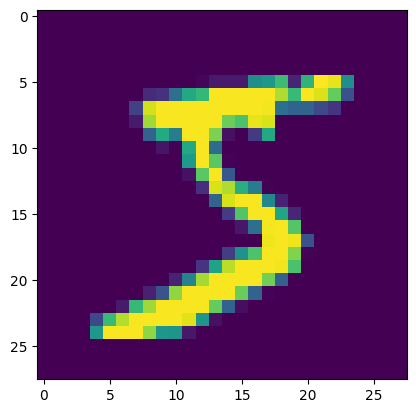

In [3]:
plt.imshow(X_train[0])
plt.show()

### **2. Pré-processamento dos dados:**

In [4]:
X_train.min(), X_train.max()

(np.uint8(0), np.uint8(255))

In [5]:
# ajsutando o tipo de entrada numérica:
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

N_train, width, _ = X_train.shape
N_test, _, _ = X_test.shape

# normalização:
Max = X_train.max()

X_train /= Max
X_test /= Max

# achatando as matrizes:
X_train = X_train.reshape((N_train, width*width))
X_test = X_test.reshape((N_test, width*width))

input_size = X_train.shape[1]

print("Tamanho da entrada:", input_size)

Tamanho da entrada: 784


In [6]:
# codificação one-hot:
y_train = tf.one_hot(y_train, depth=10)
y_test = tf.one_hot(y_test, depth=10)

y_train[0]

<tf.Tensor: shape=(10,), dtype=float32, numpy=array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.], dtype=float32)>

### **3. Modelagem e compilação do modelo:**

In [7]:
from keras import Input, layers, Model

In [8]:
x_in = Input(shape=(input_size,))

x = layers.Dense(128, activation="relu")(x_in)

x = layers.Dense(64, activation="relu")(x)

x_out = layers.Dense(10, activation="softmax")(x)

model = Model(inputs=x_in, outputs=x_out)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

<font size=3>
<br>
    
Agora, iremos definir o **otimizador**, **função de custo**, e a **métrica** para os dados de validação.

In [9]:
model.compile(optimizer="Adam", loss="categorical_crossentropy", metrics=['acc'])

### **4. Treinamento validativo:**
<font size=3>

Este é o momento que validamos a modelagem da rede neural do passo anterior. Verificamos as curvas de **treinamento** e **validação** a fim de identificar se nosso modelo está **bem ajustado**, ou sofre de **_overfitting_** ou **_underfitting_**. Caso a validação não mostre um bom desempenho, devemos voltar ao passo anterior para aprimorar a rede neural — por exemplo, alterando o número de neurônios e camadas (*hiperparâmetros*) — e **reiniciar e executar todo o código**.

**Observação:** Os dados de **validação** serão amostrados dos dados de treinamento por meio da variável `validation_split` do método `.fit()`.

In [10]:
final_training = True

n_epochs = 10
batch_saize = 32

if not final_training:

    # treinamento validativo:
    report = model.fit(x=X_train, y=y_train, validation_split=0.2,
                       epochs=n_epochs, batch_size=batch_saize)

    # plotando as métricas ao longo das épocas:
    loss = report.history['loss']
    acc = report.history['acc']

    val_loss = report.history['val_loss']
    val_acc = report.history['val_acc']

    epochs = np.linspace(1, len(loss), len(loss))

    fig, ax = plt.subplots(1, 2, figsize=(16, 5))

    ax[0].plot(epochs, loss, label='CE')
    ax[0].plot(epochs, val_loss, label='val-CE')

    ax[1].plot(epochs, acc, label='Acc')
    ax[1].plot(epochs, val_acc, label='val-Acc')

    for i in range(2):
        ax[i].set_xlabel("Epochs")
        ax[i].legend()
        ax[i].grid()

    plt.show()


### **5. Treinamento final:**
<font size=3>

Com a nossa rede bem modelada, agora, faremos o treinamento do modelo final, *juntando* os dados de treinamento e validação.

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - acc: 0.9286 - loss: 0.2343
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.9700 - loss: 0.0986
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.9780 - loss: 0.0698
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.9834 - loss: 0.0531
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.9864 - loss: 0.0424
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.9891 - loss: 0.0346
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.9905 - loss: 0.0299
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.9919 - loss: 0.0244
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.9928 - loss: 0.0212
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.9931 - loss: 0.0201


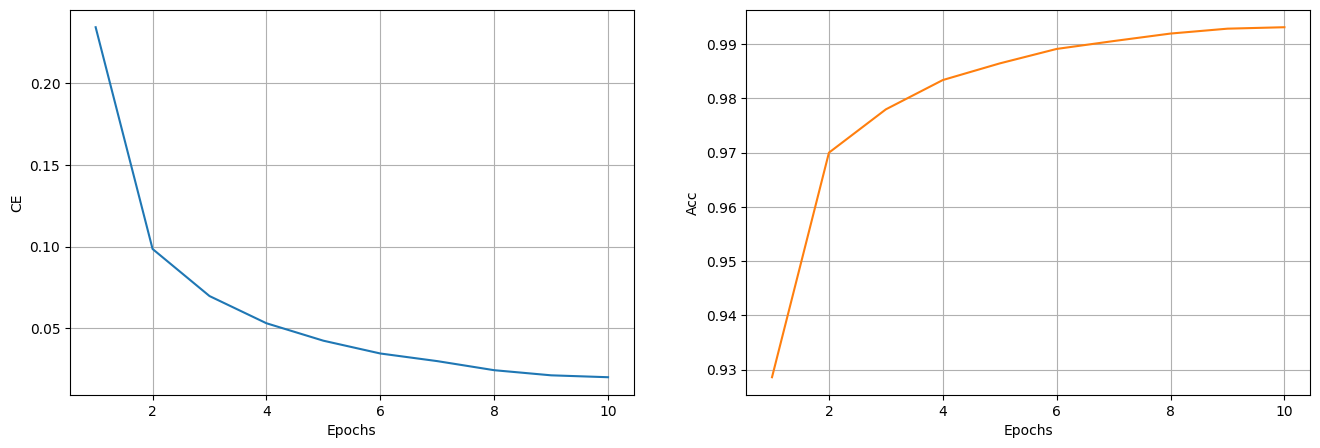

In [11]:
if final_training:

    # treinamento do modelo final:
    report = model.fit(x=X_train, y=y_train, epochs=n_epochs, batch_size=batch_saize)

    # plotando as métricas ao longo das épocas:
    loss = report.history['loss']
    acc = report.history['acc']

    epochs = np.linspace(1, len(loss), len(loss))

    fig, ax = plt.subplots(1, 2, figsize=(16, 5))

    ax[0].plot(epochs, loss, c='tab:blue')
    ax[1].plot(epochs, acc, c='tab:orange')

    ax[0].set_ylabel('CE')
    ax[1].set_ylabel('Acc')

    for i in range(2):
        ax[i].set_xlabel("Epochs")
        ax[i].grid()

    plt.show()


### **6. Avaliação do modelo:**
<font size=3>

Avaliando o modelo com os dados de teste.

In [12]:
if final_training:
    ce, acc = model.evaluate(x=X_test, y=y_test, batch_size=batch_saize)

    print(f"\nCE = {ce:.4f}, acc = {acc:.4f}\n")


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9757 - loss: 0.0983

CE = 0.0983, acc = 0.9757



In [13]:
if final_training:

    y_pred = model.predict(X_test)

    print("\ny-pred | y-test")
    print("---------------")

    for p, y in zip(y_pred[:10], y_test[:10]):

        print(f" {np.argmax(p)}  |  {np.argmax(y)}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

y-pred | y-test
---------------
 7  |  7
 2  |  2
 1  |  1
 0  |  0
 4  |  4
 1  |  1
 4  |  4
 9  |  9
 6  |  5
 9  |  9
